In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn. linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# - Load the dataset and split it into training and testing sets.

data = pd.read_csv('spam_data.csv')

X = data.drop(['Prediction', 'Email No.'], axis=1)
y = data['Prediction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [8]:
# - Train the Logistic Regression model to classify emails as spam or not spam.

model = LogisticRegression(max_iter=1000)
# Note: max_iter is increased to 1000 to allow the optimization algorithm enough iterations 
#to fully converge and prevent warnings.
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [9]:
# - Evaluate the model using accuracy, confusion matrix, precision, recall, and F1-score.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1_score: {f1}")

Accuracy: 0.9719806763285024
Precision: 0.9435215946843853
Recall: 0.9594594594594594
F1_score: 0.9514237855946399


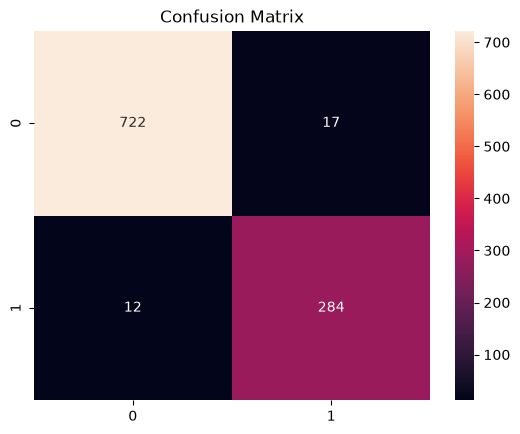

In [10]:
# - Visualize the confusion matrix using Seaborn's heatmap.
cm = confusion_matrix(y_test, y_pred)
sns. heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

In [11]:
sample_data = X_test.sample(5, random_state=5)
actual_labels = y_test.loc[sample_data.index]

sample_predictions = model.predict(sample_data)

# ප්‍රතිඵල සංසන්දනය කර බැලීම
print("Email ID   | Actual     | Predicted  | Correct?")
print("-" * 45)

for index, actual, predicted in zip(sample_data.index, actual_labels, sample_predictions):
    actual_text = "Spam" if actual == 1 else "Normal"
    pred_text = "Spam" if predicted == 1 else "Normal"
    status = "✅ Yes" if actual == predicted else "❌ No"
    
    print(f"{index:<10} | {actual_text:<10} | {pred_text:<10} | {status}")

Email ID   | Actual     | Predicted  | Correct?
---------------------------------------------
387        | Normal     | Spam       | ❌ No
2630       | Spam       | Spam       | ✅ Yes
252        | Normal     | Normal     | ✅ Yes
1946       | Normal     | Normal     | ✅ Yes
798        | Spam       | Spam       | ✅ Yes
